# Iteración 27: Nixtla como Fábrica de Features + Modelos Tabulares Directos (12W Horizon)

## Contexto y Motivación
La iteración anterior (NB27 roto) usaba MLForecast en modo **autoregresivo** (predicción semana a semana), lo que genera acumulación de error e incompatibilidad con `target_12w_ahead` — el target real de CRUZBER. WMAPEs de 42-177%.

**Solución (Camino B):** Usar `MLForecast.preprocess()` como **generador automático de features temporales** (lags, rolling, EWM), extraer la matriz resultante, y entrenar modelos tabulares directos (CatBoost + LightGBM) contra `target_12w_ahead` — exactamente como en iter 25b pero con Nixtla generando las features.

| Referencia | WMAPE Global | R² | Smooth/Erratic | Hurdle |
|---|---|---|---|---|
| Iter 23 | 35.2% | 0.901 | 24.0% | ~54.7% |
| Iter 25b | 31.0% | 0.939 | 22.7% | 47.0% |
| **Iter 27 (objetivo)** | **≤31%** | **>0.93** | **<25%** | **<55%** |


### Paso 0: Preparación del Entorno S&OP con Nixtla + Tabulares
**¿Qué hacemos?** Cargamos librerías base, el ecosistema Nixtla y los frameworks de boosting tabular.
**¿Por qué?** Esta iteración combina lo mejor de dos mundos: Nixtla para feature engineering automático, CatBoost/LightGBM para modelado tabular directo contra el target S&OP real.


In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from IPython.display import display, Markdown

# Nixtla: feature engineering automatico
from mlforecast import MLForecast
from mlforecast.lag_transforms import RollingMean, RollingStd, ExponentiallyWeightedMean

# Statsforecast: benchmark intermitentes
from statsforecast import StatsForecast
from statsforecast.models import CrostonOptimized, CrostonSBA, ADIDA

# Tabulares: modelado directo
from catboost import CatBoostRegressor, CatBoostClassifier, Pool
import lightgbm as lgb
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

sns.set_theme(style='whitegrid', palette='mako')
pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', '{:.4f}'.format)

SEED     = 42
DATA_DIR = Path('../Datasets/Datos Internos')
print('Librerias listas.')


Librerias listas.


### Paso 1: Inteligencia de Negocio, Constantes y Funciones Base
**¿Qué hacemos?** Definimos el flag `QUICK_MODE`, constantes de calendario y la función de métricas `wmape`.
**¿Por qué?** `QUICK_MODE=True` usa los 200 SKUs de mayor volumen para iteración rápida de desarrollo. El WMAPE ponderado es la métrica principal de CRUZBER por su interpretabilidad en unidades de negocio.


In [2]:
# FLAG MODO RAPIDO (cambiar a False para produccion S&OP)
QUICK_MODE = True

if QUICK_MODE:
    print('MODO RAPIDO: Top 200 SKUs, n_trials=5, 1 fold.')
else:
    print('PRODUCCION: Catalogo completo, n_trials=25, 3 folds.')

ANIOS_TRAIN = [2021, 2022, 2023]
ANIO_TEST   = 2024

FESTIVOS_FIJOS = [
    (1,1),(1,6),(5,1),(8,15),(10,12),(11,1),(12,6),(12,8),(12,25)
]
VIERNES_SANTOS = {
    2020:'2020-04-10', 2021:'2021-04-02', 2022:'2022-04-15',
    2023:'2023-04-07', 2024:'2024-03-29', 2025:'2025-04-18',
}
MESES_ES = {
    'enero':1,'febrero':2,'marzo':3,'abril':4,'mayo':5,'junio':6,
    'julio':7,'agosto':8,'septiembre':9,'octubre':10,'noviembre':11,'diciembre':12
}

def parse_fecha_es(s):
    try:
        _, resto = str(s).split(', ', 1)
        day, _, month_es, _, year = resto.strip().split()
        return pd.Timestamp(year=int(year), month=MESES_ES[month_es.lower()], day=int(day))
    except Exception:
        return pd.NaT

def wmape(y_true, y_pred):
    """WMAPE global ponderado por volumen real."""
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denom = np.sum(np.abs(y_true))
    return 100 * np.sum(np.abs(y_true - y_pred)) / max(denom, 1)

def print_metrics(nombre, y_true, y_pred, df_te=None):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    mae = np.mean(np.abs(y_true - y_pred))
    wm  = wmape(y_true, y_pred)
    ss_r = np.sum((y_true - y_pred)**2)
    ss_t = np.sum((y_true - np.mean(y_true))**2)
    r2   = 1 - ss_r/ss_t if ss_t > 0 else 0
    bias = np.mean(y_pred - y_true)
    print(f'[{nombre}]  N={len(y_true):,}  MAE={mae:.1f}  WMAPE={wm:.1f}%  R2={r2:.3f}  Bias={bias:.2f}')
    if df_te is not None and 'tipo_abc' in df_te.columns:
        for cls in ['A','B','C']:
            m = (df_te['tipo_abc'] == cls).values
            if m.sum() > 0:
                wm_c = wmape(y_true[m], y_pred[m])
                print(f'   Clase {cls}  N={m.sum():4d}  WMAPE={wm_c:.1f}%')
    return wm

print('Constantes y funciones listas.')


MODO RAPIDO: Top 200 SKUs, n_trials=5, 1 fold.
Constantes y funciones listas.


### Paso 2: Ingesta del 'Data Lake' Operativo
**¿Qué hacemos?** Cargamos transacciones, maestros de artículos y familias, clientes, canales, clima semanal y calendario de ciclismo.
**¿Por qué?** CRUZBER vende principalmente en el canal B2B nacional (excluye FLEET y export). Las variables exógenas (clima, ciclismo, festivos) mejoran la precisión en demanda estacional.


In [3]:
# Transacciones
df_raw = pd.read_excel(DATA_DIR / 'LineasAlbaranCliente.xlsx')
df_raw['fecha']           = df_raw['FechaAlbaran'].astype(str).apply(parse_fecha_es)
df_raw                    = df_raw.dropna(subset=['fecha'])
df_raw['anio']            = df_raw['fecha'].dt.isocalendar().year.astype(int)
df_raw['semana_anio']     = df_raw['fecha'].dt.isocalendar().week.astype(int)
df_raw['codigo_articulo'] = df_raw['CodigoArticulo'].astype(str).str.strip()
df_raw['Unidades']        = pd.to_numeric(df_raw['Unidades'],    errors='coerce').fillna(0)
df_raw['ImporteNeto']     = pd.to_numeric(df_raw['ImporteNeto'], errors='coerce').fillna(0)
df_raw['pct_desc2']       = pd.to_numeric(df_raw['%Descuento2'], errors='coerce').fillna(0)
print(f'Transacciones: {len(df_raw):,} filas')

# Maestro articulos
df_art = pd.read_excel(
    DATA_DIR / 'MaestroArticulos.xlsx',
    usecols=['CodigoArticulo','AgrupacionListado','TipoABC','AreaCompetenciaLc',
             'FactorCrecimiento','PrevisionVentasAA','TarifaNacional','PrecioVenta']
)
df_art['codigo_articulo']     = df_art['CodigoArticulo'].astype(str).str.strip()
df_art['tipo_abc']            = df_art['TipoABC'].fillna('C').astype(str).str.upper().str[:1]
df_art['factor_crecimiento']  = pd.to_numeric(df_art['FactorCrecimiento'],  errors='coerce').fillna(1.0)
df_art['prevision_ventas_aa'] = pd.to_numeric(df_art['PrevisionVentasAA'],  errors='coerce').fillna(0.0)
df_art['tarifa_nacional']     = pd.to_numeric(df_art['TarifaNacional'],     errors='coerce').fillna(0.0)
df_art['precio_unit']         = pd.to_numeric(df_art['PrecioVenta'],        errors='coerce').fillna(0.0)

# Familias / Gamas de producto
df_fam = pd.read_excel(
    DATA_DIR / 'Familias Articulos.xlsx',
    usecols=['AgrupacionListado','CR_GamaProducto','CR_TipoProducto','CR_MaterialAgrupacion']
)
for col in ['CR_GamaProducto','CR_TipoProducto','CR_MaterialAgrupacion']:
    df_fam[col] = df_fam[col].fillna('DESCONOCIDO').astype(str)

# Maestro clientes y canales
df_cli = pd.read_excel(DATA_DIR / 'MaestroClientes.xlsx',
                       usecols=['CodigoCliente','CodigoNacion'])
df_can = pd.read_excel(DATA_DIR / 'Agrupacion Canales venta.xlsx', header=0)
df_can.columns = ['canal_raw','agrupacion_canal','tipo_agrupacion'] + list(df_can.columns[3:])

# Clima semanal nacional
df_clima = pd.read_csv('../Datasets/clima_semanal_openmeteo.csv')
df_clima.columns = [c.lower() for c in df_clima.columns]
df_clima_nac = (
    df_clima.groupby(['year','semana'])
    .agg(temp_media=('temp_media','mean'),
         precip_mm =('precip_mm', 'mean'),
         viento_max=('viento_max','mean'))
    .reset_index()
    .rename(columns={'year':'anio','semana':'semana_anio'})
)

# Calendario ciclismo
df_cicl = pd.read_excel('../Datasets/Calendario Ciclismo 22_24.xlsx')
df_cicl.columns = [c.strip() for c in df_cicl.columns]
df_cicl_agg = (
    df_cicl
    .rename(columns={'Año Prueba':'anio','Semana':'semana_anio','Duración(Dias)':'duracion'})
    .groupby(['anio','semana_anio'])
    .agg(num_pruebas_cicl=('anio','count'), dias_pruebas_cicl=('duracion','sum'))
    .reset_index()
)
df_cicl_agg['hubo_prueba_cicl'] = 1

print('Data lake completo ingerido.')


Transacciones: 938,230 filas
Data lake completo ingerido.


### Paso 3: Filtrado Quirúrgico B2B y Agregación Semanal
**¿Qué hacemos?** Separamos el canal FLEET, aplicamos el filtro nacional España (CodigoNacion=108), excluimos 2020 (COVID) y agregamos ventas a nivel SKU-semana con descuento ponderado.
**¿Por qué?** El FLEET tiene patrones de demanda completamente distintos (licitaciones masivas). El mercado nacional sin FLEET representa el negocio regular de distribución B2B que queremos predecir.


In [4]:
# Merge canales
df_raw = df_raw.merge(df_can[['canal_raw','agrupacion_canal']],
                      left_on='SerieAlbaran', right_on='canal_raw', how='left')
df_raw['agrupacion_canal'] = df_raw['agrupacion_canal'].fillna('Otros')
df_raw = df_raw.merge(df_cli[['CodigoCliente','CodigoNacion']], on='CodigoCliente', how='left')

# Filtros: nacional + sin FLEET + desde 2021
df_nac = df_raw[
    (df_raw['CodigoNacion'] == 108) &
    (df_raw['agrupacion_canal'] != 'FLEET') &
    (df_raw['anio'] >= 2021)
].copy()
print(f'Nacional sin FLEET (desde 2021): {len(df_nac):,} filas')

# dias_laborables por semana ISO
def get_festivos_espana(anios):
    festivos = set()
    for y in anios:
        for m, d in FESTIVOS_FIJOS:
            festivos.add((y, m, d))
        if y in VIERNES_SANTOS:
            vs = pd.Timestamp(VIERNES_SANTOS[y])
            festivos.add((vs.year, vs.month, vs.day))
    return festivos

def dias_laborables_iso(year, week, festivos_set):
    try:
        lunes = pd.Timestamp.fromisocalendar(int(year), int(week), 1)
    except ValueError:
        return 5
    return sum(1 for d in range(5)
               if (lunes + pd.Timedelta(days=d)).timetuple()[:3] not in festivos_set)

festivos_set = get_festivos_espana(range(2021, 2026))
semanas_unicas = df_nac[['anio','semana_anio']].drop_duplicates().copy()
semanas_unicas['dias_laborables_semana'] = semanas_unicas.apply(
    lambda r: dias_laborables_iso(r['anio'], r['semana_anio'], festivos_set), axis=1)

# Agregacion SKU-semana
GROUP_NAC = ['anio', 'semana_anio', 'codigo_articulo']
df_agg = df_nac.groupby(GROUP_NAC, as_index=False).agg(unidades=('Unidades','sum'))
df_agg['unidades'] = df_agg['unidades'].clip(lower=0)

def wmean_desc(g):
    w = g['Unidades'].abs(); v = g['pct_desc2']; denom = w.sum()
    return (v * w).sum() / denom if denom > 0 else 0.0

desc_agg = df_nac.groupby(GROUP_NAC).apply(wmean_desc).reset_index(name='por_descuento2')
df_agg   = df_agg.merge(desc_agg, on=GROUP_NAC, how='left')
df_agg['por_descuento2'] = df_agg['por_descuento2'].fillna(0.0)
print(f'Transacciones agregadas: {len(df_agg):,} filas SKU-semana')


Nacional sin FLEET (desde 2021): 453,846 filas
Transacciones agregadas: 125,196 filas SKU-semana


### Paso 4: Densificación de Panel e Inyección Exógena
**¿Qué hacemos?** Construimos la grilla completa SKUs x Semanas (Dense Panel), rellenando ceros donde no hubo ventas. Después inyectamos variables climáticas, ciclismo y días laborables.
**¿Por qué?** Los lags y rolling de Nixtla necesitan una serie temporal continua para ser correctos. Si hay semanas faltantes, lag_1 no sería la semana anterior real sino una semana anterior arbitraria.


In [5]:
# Dense Panel
semanas_grid = semanas_unicas[['anio','semana_anio']].copy()
semanas_grid['key'] = 1
skus_grid = pd.DataFrame({'codigo_articulo': df_nac['codigo_articulo'].unique(), 'key': 1})
dense_grid = semanas_grid.merge(skus_grid, on='key').drop(columns=['key'])

df_agg = dense_grid.merge(df_agg, on=['codigo_articulo','anio','semana_anio'], how='left')
df_agg['unidades']       = df_agg['unidades'].fillna(0)
df_agg['por_descuento2'] = df_agg['por_descuento2'].fillna(0)

# Variables exogenas
df_agg = df_agg.merge(semanas_unicas,  on=['anio','semana_anio'], how='left')
df_agg = df_agg.merge(df_clima_nac,    on=['anio','semana_anio'], how='left')
df_agg = df_agg.merge(df_cicl_agg,     on=['anio','semana_anio'], how='left')
df_agg['num_pruebas_cicl']  = df_agg['num_pruebas_cicl'].fillna(0).astype(int)
df_agg['dias_pruebas_cicl'] = df_agg['dias_pruebas_cicl'].fillna(0)
df_agg['hubo_prueba_cicl']  = df_agg['hubo_prueba_cicl'].fillna(0).astype(int)

# tipo_abc desde maestro
df_agg = df_agg.merge(df_art[['codigo_articulo','tipo_abc']], on='codigo_articulo', how='left')
df_agg['tipo_abc'] = df_agg['tipo_abc'].fillna('C')

df_agg = df_agg.sort_values(['codigo_articulo','anio','semana_anio']).reset_index(drop=True)
print(f'Dense Panel: {len(df_agg):,} filas  |  SKUs: {df_agg["codigo_articulo"].nunique():,}')
print(f'Anios: {sorted(df_agg["anio"].unique())}')


Dense Panel: 646,425 filas  |  SKUs: 3,315
Anios: [np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]


### Paso 4.5: QUICK_MODE — Filtro Top SKUs
**¿Qué hacemos?** Si `QUICK_MODE=True`, reducimos el catálogo a los **200 SKUs de mayor volumen total** medido sobre el historial completo.
**¿Por qué?** El filtro se aplica DESPUES del Dense Panel para garantizar que las series temporales sean correctas. Filtrar antes sesgaría la densificación.


In [6]:
if QUICK_MODE:
    vol_sku  = df_agg.groupby('codigo_articulo')['unidades'].sum()
    top_skus = vol_sku.nlargest(200).index.tolist()
    df_agg   = df_agg[df_agg['codigo_articulo'].isin(top_skus)].copy()
    print(f'QUICK_MODE: reducido a {df_agg["codigo_articulo"].nunique()} SKUs top volumen.')
else:
    print(f'Produccion: usando {df_agg["codigo_articulo"].nunique()} SKUs.')


QUICK_MODE: reducido a 200 SKUs top volumen.


### Paso 5: Target Temporal Acumulado (12 Semanas Vista)
**¿Qué hacemos?** Para cada fila SKU-semana calculamos la **suma de unidades vendidas en las 12 semanas futuras inmediatas** (T+1 a T+12). Las últimas 12 semanas de cada SKU se eliminan por data leakage.
**¿Por qué?** CRUZBER necesita visibilidad S&OP a 3 meses vista para planificar compras de materia prima y lotes de extrusión. Este es exactamente el mismo target de las iters 23 y 25b, lo que garantiza comparación justa.


In [7]:
# Target acumulado 12 semanas
df_agg = df_agg.sort_values(['codigo_articulo','anio','semana_anio']).reset_index(drop=True)

df_agg['target_12w_ahead'] = df_agg.groupby('codigo_articulo')['unidades'].transform(
    lambda x: sum(x.shift(-h) for h in range(1, 13))
)

n_antes = len(df_agg)
df_agg  = df_agg.dropna(subset=['target_12w_ahead']).copy()
print(f'Filas antes de purgar: {n_antes:,}  |  Tras eliminar ultimas 12 semanas: {len(df_agg):,}')
print(f'target_12w_ahead  mean={df_agg["target_12w_ahead"].mean():.1f}  median={df_agg["target_12w_ahead"].median():.1f}')


Filas antes de purgar: 39,000  |  Tras eliminar ultimas 12 semanas: 36,600
target_12w_ahead  mean=141.0  median=76.0


### Paso 5b: Clasificación Estadística de Demanda (Syntetos-Boylan)
**¿Qué hacemos?** Calculamos CV2 (coeficiente de variación al cuadrado) y ADI (Average Demand Interval) sobre el período de train (2021-2023). Clasificamos cada SKU en uno de cuatro cuadrantes usando umbrales estándar: CV2=0.49, ADI=1.32.
**¿Por qué?** La demanda intermitente y lumpy requiere un paradigma diferente (Hurdle Model). Mezclar ambos tipos en un único modelo penaliza a los productos de alta rotación.


Distribucion Syntetos-Boylan:
sb_class
Erratic         100
Smooth           66
Intermittent     20
Lumpy            14
Name: count, dtype: int64


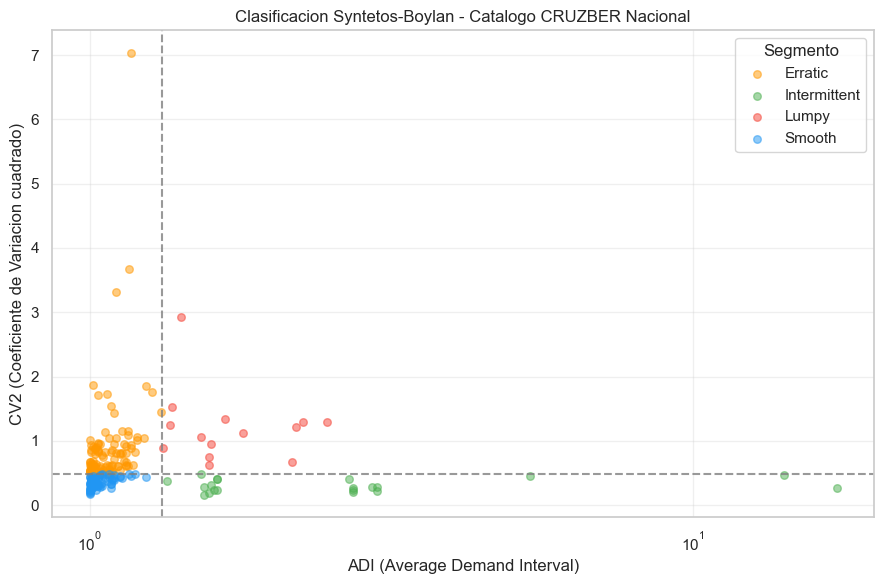

In [8]:
# Clasificacion Syntetos-Boylan (solo sobre train)
train_sub = df_agg[df_agg['anio'].isin(ANIOS_TRAIN)].copy()

demand_stats = (
    train_sub[train_sub['unidades'] > 0]
    .groupby('codigo_articulo')
    .agg(mean_demand=('unidades','mean'),
         std_demand =('unidades','std'),
         count_demand=('codigo_articulo','count'))
)
demand_stats['CV2'] = (demand_stats['std_demand'] / demand_stats['mean_demand']) ** 2

total_periods = train_sub.groupby('codigo_articulo').size()
demand_stats['total_periods'] = total_periods
demand_stats['ADI'] = demand_stats['total_periods'] / demand_stats['count_demand']
demand_stats['CV2'] = demand_stats['CV2'].fillna(0)

def classify_sb(row):
    adi, cv2 = row['ADI'], row['CV2']
    if pd.isna(adi) or np.isinf(adi): return 'Lumpy'
    if   adi < 1.32 and cv2 < 0.49:  return 'Smooth'
    elif adi < 1.32 and cv2 >= 0.49: return 'Erratic'
    elif adi >= 1.32 and cv2 < 0.49: return 'Intermittent'
    else:                            return 'Lumpy'

demand_stats['sb_class'] = demand_stats.apply(classify_sb, axis=1)

df_agg = df_agg.merge(demand_stats[['sb_class','ADI','CV2']], on='codigo_articulo', how='left')
df_agg['sb_class'] = df_agg['sb_class'].fillna('Lumpy')

print('Distribucion Syntetos-Boylan:')
print(df_agg.drop_duplicates('codigo_articulo')['sb_class'].value_counts())

# Scatter plot cuadrantes
fig, ax = plt.subplots(figsize=(9,6))
colors = {'Smooth':'#2196F3','Erratic':'#FF9800','Intermittent':'#4CAF50','Lumpy':'#F44336'}
sku_stats = df_agg.drop_duplicates('codigo_articulo')[['codigo_articulo','ADI','CV2','sb_class']].copy()
for cls, grp in sku_stats.groupby('sb_class'):
    ax.scatter(grp['ADI'], grp['CV2'], alpha=0.5, s=30, color=colors[cls], label=cls)
ax.axvline(1.32, color='gray', linestyle='--', lw=1.5, alpha=0.8)
ax.axhline(0.49, color='gray', linestyle='--', lw=1.5, alpha=0.8)
ax.set_xlabel('ADI (Average Demand Interval)')
ax.set_ylabel('CV2 (Coeficiente de Variacion cuadrado)')
ax.set_title('Clasificacion Syntetos-Boylan - Catalogo CRUZBER Nacional')
ax.set_xscale('log'); ax.legend(title='Segmento'); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


### Paso 6: MLForecast como Generador de Features (No como Predictor)
**¿Qué hacemos?** Usamos `MLForecast.preprocess()` para que Nixtla construya automáticamente lags, rolling means, rolling stds y EWMs. Extraemos la matriz de features resultante y la usamos como input para modelos tabulares directos contra `target_12w_ahead`.
**¿Por qué?** Nixtla automatiza en segundos lo que en iter 23 costó ~100 líneas de código manual. Pero el paradigma autoregresivo de MLForecast no encaja con un target acumulado a 12 semanas. Obtenemos lo mejor de ambos mundos: **comodidad de Nixtla + target correcto para S&OP**.


In [9]:
# Segmentar antes de generar features para eficiencia
df_reg_raw = df_agg[df_agg['sb_class'].isin(['Smooth','Erratic'])].copy()
df_hrd_raw = df_agg[df_agg['sb_class'].isin(['Intermittent','Lumpy'])].copy()
print(f'Smooth/Erratic: {len(df_reg_raw):,} filas  |  {df_reg_raw["codigo_articulo"].nunique()} SKUs')
print(f'Intermittent/Lumpy: {len(df_hrd_raw):,} filas  |  {df_hrd_raw["codigo_articulo"].nunique()} SKUs')


Smooth/Erratic: 30,378 filas  |  166 SKUs
Intermittent/Lumpy: 6,222 filas  |  34 SKUs


In [10]:
# Configuracion de features Nixtla
LAGS_NIXTLA = [1, 2, 3, 4, 8, 12, 26, 52]

LAG_TRANSFORMS = {
    1:  [RollingMean(window_size=4),  RollingStd(window_size=4),
         ExponentiallyWeightedMean(alpha=0.3)],
    4:  [RollingMean(window_size=12), RollingStd(window_size=12)],
    12: [RollingMean(window_size=4),  RollingStd(window_size=4)],
    52: [RollingMean(window_size=4)],
}

DATE_FEATURES = ['month', 'week', 'quarter']

def df_a_nixtla(df_seg):
    """Convierte Dense Panel a formato Nixtla (unique_id, ds, y)."""
    df_n = df_seg[['codigo_articulo','anio','semana_anio','unidades']].copy()
    df_n['ds'] = df_n.apply(
        lambda r: pd.Timestamp.fromisocalendar(int(r['anio']), int(r['semana_anio']), 1),
        axis=1
    )
    df_n = df_n.rename(columns={'codigo_articulo':'unique_id','unidades':'y'})
    return df_n[['unique_id','ds','y']].sort_values(['unique_id','ds']).reset_index(drop=True)

def build_nixtla_features(df_seg_nixtla, tag=''):
    """Instancia MLForecast y extrae la matriz de features via preprocess()."""
    from sklearn.linear_model import LinearRegression
    try:
        fcst = MLForecast(
            models=[],
            freq='W-MON',
            lags=LAGS_NIXTLA,
            lag_transforms=LAG_TRANSFORMS,
            date_features=DATE_FEATURES,
            num_threads=1,
        )
        df_feat = fcst.preprocess(df_seg_nixtla)
    except Exception as e:
        print(f'models=[] no soportado ({e}). Usando LinearRegression dummy.')
        fcst = MLForecast(
            models=[LinearRegression()],
            freq='W-MON',
            lags=LAGS_NIXTLA,
            lag_transforms=LAG_TRANSFORMS,
            date_features=DATE_FEATURES,
            num_threads=1,
        )
        df_feat = fcst.preprocess(df_seg_nixtla)
    feat_cols = [c for c in df_feat.columns if c not in ['unique_id','ds','y']]
    print(f'{tag} | Features Nixtla generadas ({len(feat_cols)}): {feat_cols}')
    return df_feat, feat_cols

print('=== GENERANDO FEATURES: Smooth/Erratic ===')
df_nixtla_reg = df_a_nixtla(df_reg_raw)
df_feat_reg, FEAT_NIXTLA_COLS = build_nixtla_features(df_nixtla_reg, tag='REG')

print('\n=== GENERANDO FEATURES: Intermittent/Lumpy ===')
df_nixtla_hrd = df_a_nixtla(df_hrd_raw)
df_feat_hrd, _ = build_nixtla_features(df_nixtla_hrd, tag='HRD')


=== GENERANDO FEATURES: Smooth/Erratic ===
REG | Features Nixtla generadas (19): ['lag1', 'lag2', 'lag3', 'lag4', 'lag8', 'lag12', 'lag26', 'lag52', 'rolling_mean_lag1_window_size4', 'rolling_std_lag1_window_size4', 'exponentially_weighted_mean_lag1_alpha0.3', 'rolling_mean_lag4_window_size12', 'rolling_std_lag4_window_size12', 'rolling_mean_lag12_window_size4', 'rolling_std_lag12_window_size4', 'rolling_mean_lag52_window_size4', 'month', 'week', 'quarter']

=== GENERANDO FEATURES: Intermittent/Lumpy ===
HRD | Features Nixtla generadas (19): ['lag1', 'lag2', 'lag3', 'lag4', 'lag8', 'lag12', 'lag26', 'lag52', 'rolling_mean_lag1_window_size4', 'rolling_std_lag1_window_size4', 'exponentially_weighted_mean_lag1_alpha0.3', 'rolling_mean_lag4_window_size12', 'rolling_std_lag4_window_size12', 'rolling_mean_lag12_window_size4', 'rolling_std_lag12_window_size4', 'rolling_mean_lag52_window_size4', 'month', 'week', 'quarter']


In [11]:
# Recuperar anio/semana_anio desde ds y eliminar NaN en lags
for df_f in [df_feat_reg, df_feat_hrd]:
    iso = df_f['ds'].dt.isocalendar()
    df_f['anio']        = iso.year.astype(int)
    df_f['semana_anio'] = iso.week.astype(int)
    df_f.rename(columns={'unique_id':'codigo_articulo'}, inplace=True)

n_antes_reg = len(df_feat_reg)
df_feat_reg = df_feat_reg.dropna(subset=FEAT_NIXTLA_COLS).reset_index(drop=True)
n_antes_hrd = len(df_feat_hrd)
df_feat_hrd = df_feat_hrd.dropna(subset=FEAT_NIXTLA_COLS).reset_index(drop=True)

print(f'REG: {n_antes_reg:,} -> {len(df_feat_reg):,} filas tras eliminar NaN en lags iniciales')
print(f'HRD: {n_antes_hrd:,} -> {len(df_feat_hrd):,} filas tras eliminar NaN en lags iniciales')


REG: 21,248 -> 21,248 filas tras eliminar NaN en lags iniciales
HRD: 4,352 -> 4,352 filas tras eliminar NaN en lags iniciales


### Paso 7: Atributos Estáticos de Producto y Target Encoding
**¿Qué hacemos?** Inyectamos las variables que Nixtla NO puede generar: gama/tipo de producto (CR_*), previsión comercial, precio, factor de crecimiento. Aplicamos target encoding con Bayesian shrinkage sobre train.
**¿Por qué?** Los árboles de decisión manejan bien las categóricas, pero el target encoding aporta señal ordinal que mejora la partición. El shrinkage evita overfitting en categorías con pocas observaciones.


In [12]:
# Tabla de atributos de producto
df_art_full = df_art.merge(df_fam, on='AgrupacionListado', how='left')
for col in ['CR_GamaProducto','CR_TipoProducto','CR_MaterialAgrupacion']:
    df_art_full[col] = df_art_full[col].fillna('DESCONOCIDO').astype(str)
df_art_full['AreaCompetenciaLc'] = df_art_full['AreaCompetenciaLc'].fillna('SIN_AREA').astype(str)

art_attrs = df_art_full[[
    'codigo_articulo','tipo_abc','factor_crecimiento','prevision_ventas_aa',
    'tarifa_nacional','precio_unit','AreaCompetenciaLc',
    'CR_GamaProducto','CR_TipoProducto','CR_MaterialAgrupacion'
]].drop_duplicates('codigo_articulo')

# Merge atributos en df_agg
df_agg = df_agg.merge(art_attrs, on='codigo_articulo', how='left', suffixes=('','_art'))
for col in ['CR_GamaProducto','CR_TipoProducto','CR_MaterialAgrupacion']:
    if col not in df_agg.columns: df_agg[col] = 'DESCONOCIDO'
    df_agg[col] = df_agg[col].fillna('DESCONOCIDO').astype(str)
df_agg['AreaCompetenciaLc'] = df_agg['AreaCompetenciaLc'].fillna('SIN_AREA').astype(str)
for col_num in ['factor_crecimiento','prevision_ventas_aa','tarifa_nacional','precio_unit']:
    if col_num not in df_agg.columns: df_agg[col_num] = 0.0
    df_agg[col_num] = df_agg[col_num].fillna(0.0)
df_agg['prevision_semanal'] = df_agg['prevision_ventas_aa'] / 52.0

# Target encoding con Bayesian shrinkage (SOLO sobre train)
TRAIN_MASK_AGG = df_agg['anio'].isin(ANIOS_TRAIN)

def target_encode(df, col, target_col='unidades', train_mask=None, smooth=30):
    if train_mask is None: train_mask = pd.Series(True, index=df.index)
    global_mean = df.loc[train_mask, target_col].mean()
    stats = (df.loc[train_mask].groupby(col)[target_col]
             .agg(['mean','count']).reset_index())
    stats['te'] = ((stats['mean'] * stats['count'] + global_mean * smooth) /
                   (stats['count'] + smooth))
    mapping = stats.set_index(col)['te']
    return df[col].map(mapping).fillna(global_mean)

df_agg['te_codigo_articulo'] = target_encode(df_agg, 'codigo_articulo', train_mask=TRAIN_MASK_AGG)
df_agg['te_cr_gama']         = target_encode(df_agg, 'CR_GamaProducto',   train_mask=TRAIN_MASK_AGG)
df_agg['te_area_comp']       = target_encode(df_agg, 'AreaCompetenciaLc', train_mask=TRAIN_MASK_AGG)

print(f'Atributos mergeados. Shape df_agg: {df_agg.shape}')


Atributos mergeados. Shape df_agg: (36600, 30)


### Paso 7b: Fusion de Features Nixtla + Variables Exogenas + Target
**¿Qué hacemos?** Combinamos la matriz de features de Nixtla con el target `target_12w_ahead`, las variables exógenas (clima, ciclismo, descuento) y los atributos de producto.
**¿Por qué?** Nixtla genera solo features temporales. Los atributos de producto y las exógenas son features ortogonales que aportan valor adicional demostrado en iters anteriores.


In [13]:
# Columnas exogenas y contexto a mergejar desde df_agg
EXOG_COLS_BASE = [
    'target_12w_ahead','sb_class','tipo_abc',
    'dias_laborables_semana','por_descuento2',
    'temp_media','precip_mm','viento_max',
    'num_pruebas_cicl','dias_pruebas_cicl','hubo_prueba_cicl',
    'te_codigo_articulo','te_cr_gama','te_area_comp',
    'factor_crecimiento','prevision_semanal','tarifa_nacional','precio_unit',
    'CR_GamaProducto','CR_TipoProducto','CR_MaterialAgrupacion','AreaCompetenciaLc',
    'ADI','CV2',
]
EXOG_COLS = [c for c in EXOG_COLS_BASE if c in df_agg.columns]
MERGE_KEYS = ['codigo_articulo','anio','semana_anio']

def merge_nixtla_con_exog(df_feat, df_agg_full, exog_cols):
    subset = df_agg_full[MERGE_KEYS + exog_cols].drop_duplicates(MERGE_KEYS)
    return df_feat.merge(subset, on=MERGE_KEYS, how='inner')

df_model_reg = merge_nixtla_con_exog(df_feat_reg, df_agg, EXOG_COLS)
df_model_hrd = merge_nixtla_con_exog(df_feat_hrd, df_agg, EXOG_COLS)

# Verificar integridad sb_class
for df_m, tag, exp in [(df_model_reg,'REG',['Smooth','Erratic']),
                       (df_model_hrd,'HRD',['Intermittent','Lumpy'])]:
    wrong = ~df_m['sb_class'].isin(exp)
    if wrong.sum() > 0:
        print(f'AVISO {tag}: {wrong.sum()} filas con sb_class inesperado - corrigiendo.')

df_model_reg = df_model_reg[df_model_reg['sb_class'].isin(['Smooth','Erratic'])].copy()
df_model_hrd = df_model_hrd[df_model_hrd['sb_class'].isin(['Intermittent','Lumpy'])].copy()

print(f'df_model_reg shape: {df_model_reg.shape}')
print(f'df_model_hrd shape: {df_model_hrd.shape}')


df_model_reg shape: (21248, 48)
df_model_hrd shape: (4352, 48)


### Paso 8: Preparacion de Features, Split Temporal y Folds CV
**¿Qué hacemos?** Definimos la lista de features (Nixtla + exogenas), separamos train (2021-2023) de test (2024), y construimos la función de folds expanding window.
**¿Por qué?** Split temporal estricto para evitar data leakage. La funcion generar_folds_tss implementa la misma estrategia que iter 25b para resultados comparables.


In [14]:
target = 'target_12w_ahead'

# Detectar features dinamicamente
EXCLUIR = {
    'codigo_articulo','ds','y','anio','semana_anio',
    target,'sb_class','tipo_abc','Fecha_Inicio_Semana',
    'ADI','CV2','unidades','importe_neto',
    'CodigoArticulo','AgrupacionListado','TipoABC',
}
FEATS_CAT_NAMES = ['CR_GamaProducto','CR_TipoProducto','CR_MaterialAgrupacion','AreaCompetenciaLc']

FEATS_ALL_REG = [c for c in df_model_reg.columns if c not in EXCLUIR]
FEATS_CAT_REG = [c for c in FEATS_CAT_NAMES if c in FEATS_ALL_REG]
FEATS_ALL_HRD = [c for c in df_model_hrd.columns if c not in EXCLUIR]
FEATS_CAT_HRD = [c for c in FEATS_CAT_NAMES if c in FEATS_ALL_HRD]

# Strings en categoricas
for c in FEATS_CAT_REG: df_model_reg[c] = df_model_reg[c].astype(str).fillna('NaN')
for c in FEATS_CAT_HRD: df_model_hrd[c] = df_model_hrd[c].astype(str).fillna('NaN')

print(f'Features REG: {len(FEATS_ALL_REG)} total ({len(FEATS_CAT_REG)} categoricas)')
print(f'Features HRD: {len(FEATS_ALL_HRD)} total ({len(FEATS_CAT_HRD)} categoricas)')
print(f'Features Nixtla: {FEAT_NIXTLA_COLS}')


Features REG: 38 total (4 categoricas)
Features HRD: 38 total (4 categoricas)
Features Nixtla: ['lag1', 'lag2', 'lag3', 'lag4', 'lag8', 'lag12', 'lag26', 'lag52', 'rolling_mean_lag1_window_size4', 'rolling_std_lag1_window_size4', 'exponentially_weighted_mean_lag1_alpha0.3', 'rolling_mean_lag4_window_size12', 'rolling_std_lag4_window_size12', 'rolling_mean_lag12_window_size4', 'rolling_std_lag12_window_size4', 'rolling_mean_lag52_window_size4', 'month', 'week', 'quarter']


In [15]:
def generar_folds_tss(df, feats_all, feats_cat):
    """
    Expanding window temporal:
      Fold 0: Train 2021     -> Val 2022
      Fold 1: Train 2021-22  -> Val 2023
      Fold 2: Train 2021-23  -> Val 2024  (fold final = test real)
    """
    df = df.copy()
    for c in feats_cat:
        df[c] = df[c].astype(str).fillna('NaN')
    feats_num = [f for f in feats_all if f not in feats_cat]
    train_mask_imp = df['anio'].isin(ANIOS_TRAIN)
    medians = df.loc[train_mask_imp, feats_num].median()
    df[feats_num] = df[feats_num].fillna(medians).fillna(0.0)

    folds = []
    for eval_yr in [2022, 2023, 2024]:
        tr_df = df[df['anio'] <  eval_yr].copy()
        te_df = df[df['anio'] == eval_yr].copy()
        if len(tr_df) == 0 or len(te_df) == 0: continue
        X_tr = tr_df[feats_all]; y_tr = tr_df[target]
        X_te = te_df[feats_all]; y_te = te_df[target]
        folds.append((X_tr, y_tr, X_te, y_te, tr_df, te_df))
    return folds

folds_R = generar_folds_tss(df_model_reg, FEATS_ALL_REG, FEATS_CAT_REG)
folds_H = generar_folds_tss(df_model_hrd, FEATS_ALL_HRD, FEATS_CAT_HRD)

X_tr_R, y_tr_R, X_te_R, y_te_R, train_R, test_R = folds_R[-1]
X_tr_H, y_tr_H, X_te_H, y_te_H, train_H, test_H = folds_H[-1]

cat_idx_R = [FEATS_ALL_REG.index(c) for c in FEATS_CAT_REG]
cat_idx_H = [FEATS_ALL_HRD.index(c) for c in FEATS_CAT_HRD]

print(f'Fold final REG  Train: {len(X_tr_R):,}  Test: {len(X_te_R):,}')
print(f'Fold final HRD  Train: {len(X_tr_H):,}  Test: {len(X_te_H):,}')


Fold final REG  Train: 16,766  Test: 4,482
Fold final HRD  Train: 3,434  Test: 918


### Paso 8b: Optimizacion Bayesiana (CatBoost Smooth/Erratic) con Optuna
**¿Qué hacemos?** Usamos Optuna para encontrar los mejores hiperparámetros de CatBoostRegressor con Tweedie loss. QUICK_MODE limita a 5 trials; produccion usa 25.
**¿Por qué?** La demanda B2B tiene distribución cero-inflada que Tweedie modela mejor que MSE. El early stopping previene overfitting.


In [16]:
# Split interno train/val para Optuna
sem_abs_r    = X_tr_R['anio'] * 53 + X_tr_R['semana_anio']
max_s_r      = sem_abs_r.max()
eval_mask_r  = sem_abs_r > (max_s_r - 12)
train_mask_r = sem_abs_r <= (max_s_r - 12 - 4)

def objective_reg(trial):
    params = dict(
        iterations=500 if QUICK_MODE else 2000,
        learning_rate=trial.suggest_float('lr', 0.01, 0.15, log=True),
        depth=trial.suggest_int('depth', 4, 8),
        l2_leaf_reg=trial.suggest_float('l2', 1.0, 10.0),
        loss_function='Tweedie:variance_power=' + str(trial.suggest_float('twp', 1.1, 1.9)),
        random_seed=SEED, verbose=0, early_stopping_rounds=50,
    )
    pool_tr  = Pool(X_tr_R[train_mask_r], np.log1p(y_tr_R[train_mask_r].clip(0)), cat_features=cat_idx_R)
    pool_val = Pool(X_tr_R[eval_mask_r],  np.log1p(y_tr_R[eval_mask_r].clip(0)),  cat_features=cat_idx_R)
    model = CatBoostRegressor(**params)
    model.fit(pool_tr, eval_set=pool_val, use_best_model=True)
    pred = np.expm1(model.predict(Pool(X_te_R, cat_features=cat_idx_R))).clip(0)
    return wmape(y_te_R.values, pred)

study_R = optuna.create_study(direction='minimize',
    pruner=optuna.pruners.MedianPruner(n_startup_trials=3))
n_trials_r = 5 if QUICK_MODE else 25
study_R.optimize(objective_reg, n_trials=n_trials_r)
print(f'Mejores params CatBoost REG: {study_R.best_params}  |  WMAPE={study_R.best_value:.1f}%')


KeyError: 'anio'

### Paso 8c: Entrenamiento Final CatBoost y LightGBM (Smooth/Erratic)
**¿Qué hacemos?** Entrenamos el modelo CatBoost con los mejores hiperparámetros Optuna y un LightGBM baseline para comparación. Evaluamos WMAPE, R2 y bias en test 2024.


In [ ]:
# CatBoost final REG
bp_r = study_R.best_params
cat_params = dict(
    iterations=1000 if QUICK_MODE else 3000,
    learning_rate=bp_r['lr'], depth=bp_r['depth'], l2_leaf_reg=bp_r['l2'],
    loss_function='Tweedie:variance_power=' + str(bp_r['twp']),
    random_seed=SEED, verbose=0, early_stopping_rounds=50,
)
pool_tr_r  = Pool(X_tr_R[train_mask_r], np.log1p(y_tr_R[train_mask_r].clip(0)), cat_features=cat_idx_R)
pool_val_r = Pool(X_tr_R[eval_mask_r],  np.log1p(y_tr_R[eval_mask_r].clip(0)),  cat_features=cat_idx_R)
pool_te_r  = Pool(X_te_R, cat_features=cat_idx_R)

model_cat_r = CatBoostRegressor(**cat_params)
model_cat_r.fit(pool_tr_r, eval_set=pool_val_r, use_best_model=True)
pred_cat_r = np.expm1(model_cat_r.predict(pool_te_r)).clip(0)

# LightGBM baseline REG
iter_lgb = 500 if QUICK_MODE else 2000
X_tr_r_lgb = X_tr_R.copy()
X_te_r_lgb = X_te_R.copy()
X_val_r_lgb = X_tr_R[eval_mask_r].copy()
for c in FEATS_CAT_REG:
    X_tr_r_lgb[c]  = X_tr_r_lgb[c].astype('category')
    X_te_r_lgb[c]  = X_te_r_lgb[c].astype('category')
    X_val_r_lgb[c] = X_val_r_lgb[c].astype('category')

model_lgb_r = lgb.LGBMRegressor(
    n_estimators=iter_lgb, learning_rate=0.05, max_depth=6,
    objective='tweedie', tweedie_variance_power=1.5,
    random_state=SEED, verbose=-1
)
model_lgb_r.fit(
    X_tr_r_lgb[train_mask_r], np.log1p(y_tr_R[train_mask_r].clip(0)),
    eval_set=[(X_val_r_lgb, np.log1p(y_tr_R[eval_mask_r].clip(0)))],
    callbacks=[lgb.early_stopping(50, verbose=False)],
    categorical_feature=FEATS_CAT_REG,
)
pred_lgb_r = np.expm1(model_lgb_r.predict(X_te_r_lgb)).clip(0)

# Conformal prediction (intervalos de confianza)
preds_val_r = np.expm1(model_cat_r.predict(pool_val_r)).clip(0)
residuals_r = y_tr_R[eval_mask_r].values - preds_val_r
q10_r = np.quantile(residuals_r, 0.10)
q90_r = np.quantile(residuals_r, 0.90)

test_R = test_R.copy()
test_R['pred']     = pred_cat_r
test_R['real']     = y_te_R.values
test_R['pred_p10'] = (pred_cat_r + q10_r).clip(0)
test_R['pred_p90'] = (pred_cat_r + q90_r).clip(0)
test_R['bias']     = pred_cat_r - y_te_R.values

print('\n=== RESULTADOS SMOOTH/ERRATIC ===')
wmape_cat_r = print_metrics('CatBoost (Nixtla feat + Optuna)', y_te_R.values, pred_cat_r, test_R)
wmape_lgb_r = print_metrics('LightGBM (Nixtla feat)',          y_te_R.values, pred_lgb_r, test_R)

pred_R = pred_cat_r if wmape_cat_r <= wmape_lgb_r else pred_lgb_r
test_R['pred'] = pred_R
mejor_reg = 'CatBoost' if wmape_cat_r <= wmape_lgb_r else 'LightGBM'
print(f'\nModelo seleccionado REG: {mejor_reg}')


### Paso 9: Hurdle Model para Demanda Intermitente/Lumpy
**¿Qué hacemos?** Implementamos el mismo Hurdle Model que en iter 25b, pero sobre las features generadas por Nixtla. Fase 1: CatBoostClassifier binario. Fase 2: CatBoostRegressor condicional con Tweedie. Prediccion final: `np.where(prob >= threshold, volumen, 0)`.
**¿Por qué?** La demanda intermitente tiene una mezcla de distribuciones: un componente de ocurrencia (vende?) y un componente de volumen (cuanto?). El Hurdle separa estas dos fuentes de incertidumbre.


In [ ]:
# Capping dinamico por clase
for cls in ['Intermittent','Lumpy']:
    mask = (df_model_hrd['sb_class'] == cls) & (df_model_hrd[target] > 0)
    if mask.sum() > 0:
        cap = df_model_hrd.loc[mask, target].quantile(0.995)
        df_model_hrd.loc[df_model_hrd['sb_class'] == cls, target] = \
            df_model_hrd.loc[df_model_hrd['sb_class'] == cls, target].clip(upper=cap)
        print(f'  Capping {cls}: P99.5 = {cap:.0f} unidades')

# Regenerar folds con df_model_hrd capeado
folds_H = generar_folds_tss(df_model_hrd, FEATS_ALL_HRD, FEATS_CAT_HRD)
X_tr_H, y_tr_H, X_te_H, y_te_H, train_H, test_H = folds_H[-1]
cat_idx_H = [FEATS_ALL_HRD.index(c) for c in FEATS_CAT_HRD]

sem_abs_h    = X_tr_H['anio'] * 53 + X_tr_H['semana_anio']
max_s_h      = sem_abs_h.max()
eval_mask_h  = sem_abs_h > (max_s_h - 12)
train_mask_h = sem_abs_h <= (max_s_h - 12 - 4)


In [ ]:
# Optuna para Hurdle (muestra para velocidad)
np.random.seed(SEED)
sample_frac  = 0.25 if QUICK_MODE else 0.40
sample_skus_h = np.random.choice(
    df_model_hrd['codigo_articulo'].unique(),
    size=int(df_model_hrd['codigo_articulo'].nunique() * sample_frac),
    replace=False
)
df_hrd_sample = df_model_hrd[df_model_hrd['codigo_articulo'].isin(sample_skus_h)].copy()
folds_H_samp  = generar_folds_tss(df_hrd_sample, FEATS_ALL_HRD, FEATS_CAT_HRD)

def objective_hurdle(trial):
    clf_p = dict(
        iterations=300 if QUICK_MODE else 1000,
        learning_rate=trial.suggest_float('clf_lr', 0.01, 0.1, log=True),
        depth=trial.suggest_int('clf_depth', 4, 7),
        l2_leaf_reg=trial.suggest_float('clf_l2', 1.0, 10.0),
        loss_function='Logloss', random_seed=SEED, verbose=0, early_stopping_rounds=30,
    )
    reg_p = dict(
        iterations=300 if QUICK_MODE else 1000,
        learning_rate=trial.suggest_float('reg_lr', 0.01, 0.1, log=True),
        depth=trial.suggest_int('reg_depth', 4, 7),
        l2_leaf_reg=trial.suggest_float('reg_l2', 1.0, 10.0),
        loss_function='Tweedie:variance_power=' + str(trial.suggest_float('twp_h', 1.1, 1.9)),
        random_seed=SEED, verbose=0, early_stopping_rounds=30,
    )
    thr = trial.suggest_float('threshold', 0.3, 0.7)

    cv_wmapes = []
    for X_tr, y_tr, X_te, y_te, _, _ in (folds_H_samp[-1:] if QUICK_MODE else folds_H_samp):
        s = X_tr['anio']*53 + X_tr['semana_anio']; ms = s.max()
        em = s > (ms-12); tm = s <= (ms-12-4)
        if tm.sum() == 0: continue
        y_bin = (y_tr > 0).astype(int)
        clf = CatBoostClassifier(**clf_p)
        clf.fit(Pool(X_tr[tm], y_bin[tm], cat_features=cat_idx_H),
                eval_set=Pool(X_tr[em], y_bin[em], cat_features=cat_idx_H),
                use_best_model=True)
        prob = clf.predict_proba(Pool(X_te, cat_features=cat_idx_H))[:, 1]
        pos_tm = (y_tr > 0) & tm; pos_em = (y_tr > 0) & em
        if pos_tm.sum() < 5 or pos_em.sum() < 1: continue
        reg = CatBoostRegressor(**reg_p)
        reg.fit(Pool(X_tr[pos_tm], np.log1p(y_tr[pos_tm]), cat_features=cat_idx_H),
                eval_set=Pool(X_tr[pos_em], np.log1p(y_tr[pos_em]), cat_features=cat_idx_H),
                use_best_model=True)
        vol  = np.expm1(reg.predict(Pool(X_te, cat_features=cat_idx_H))).clip(0)
        pred = np.where(prob >= thr, vol, 0)
        wm   = wmape(y_te.values, pred)
        cv_wmapes.append(wm)
        trial.report(wm, 0)
        if trial.should_prune(): raise optuna.TrialPruned()
    return np.mean(cv_wmapes) if cv_wmapes else 999.0

study_H = optuna.create_study(direction='minimize',
    pruner=optuna.pruners.MedianPruner(n_startup_trials=3))
n_trials_h = 5 if QUICK_MODE else 25
study_H.optimize(objective_hurdle, n_trials=n_trials_h)
print(f'Mejores params Hurdle: {study_H.best_params}  |  WMAPE={study_H.best_value:.1f}%')


In [ ]:
# Entrenamiento Final Hurdle
bp_h  = study_H.best_params.copy()
thr_h = bp_h.pop('threshold')

clf_params_h = dict(
    iterations=800 if QUICK_MODE else 2000,
    learning_rate=bp_h['clf_lr'], depth=bp_h['clf_depth'], l2_leaf_reg=bp_h['clf_l2'],
    loss_function='Logloss', random_seed=SEED, verbose=0, early_stopping_rounds=50,
)
reg_params_h = dict(
    iterations=800 if QUICK_MODE else 2000,
    learning_rate=bp_h['reg_lr'], depth=bp_h['reg_depth'], l2_leaf_reg=bp_h['reg_l2'],
    loss_function='Tweedie:variance_power=' + str(bp_h['twp_h']),
    random_seed=SEED, verbose=0, early_stopping_rounds=50,
)

y_tr_bin_h = (y_tr_H > 0).astype(int)
model_clf_h = CatBoostClassifier(**clf_params_h)
model_clf_h.fit(
    Pool(X_tr_H[train_mask_h], y_tr_bin_h[train_mask_h], cat_features=cat_idx_H),
    eval_set=Pool(X_tr_H[eval_mask_h], y_tr_bin_h[eval_mask_h], cat_features=cat_idx_H),
    use_best_model=True
)
prob_te_h = model_clf_h.predict_proba(Pool(X_te_H, cat_features=cat_idx_H))[:, 1]

pos_tm_h = (y_tr_H > 0) & train_mask_h
pos_em_h = (y_tr_H > 0) & eval_mask_h
model_reg_h = CatBoostRegressor(**reg_params_h)
model_reg_h.fit(
    Pool(X_tr_H[pos_tm_h], np.log1p(y_tr_H[pos_tm_h]), cat_features=cat_idx_H),
    eval_set=Pool(X_tr_H[pos_em_h], np.log1p(y_tr_H[pos_em_h]), cat_features=cat_idx_H),
    use_best_model=True
)
vol_te_h = np.expm1(model_reg_h.predict(Pool(X_te_H, cat_features=cat_idx_H))).clip(0)
pred_H   = np.where(prob_te_h >= thr_h, vol_te_h, 0)

# Conformal intervals
if pos_em_h.sum() > 0:
    preds_val_h = np.expm1(model_reg_h.predict(
        Pool(X_tr_H[pos_em_h], cat_features=cat_idx_H))).clip(0)
    residuals_h = y_tr_H[pos_em_h].values - preds_val_h
    q10_h = np.quantile(residuals_h, 0.10)
    q90_h = np.quantile(residuals_h, 0.90)
else:
    q10_h, q90_h = 0, 0

test_H = test_H.copy()
test_H['pred']     = pred_H
test_H['real']     = y_te_H.values
test_H['pred_p10'] = np.where(prob_te_h >= thr_h, (vol_te_h + q10_h).clip(0), 0)
test_H['pred_p90'] = np.where(prob_te_h >= thr_h, (vol_te_h + q90_h).clip(0), 0)
test_H['bias']     = pred_H - y_te_H.values

print('\n=== RESULTADOS INTERMITTENT/LUMPY HURDLE ===')
wmape_hurdle = print_metrics('Hurdle (CatBoost clf+reg, Nixtla feat)', y_te_H.values, pred_H, test_H)


### Paso 9b: StatsForecast como Benchmark Intermitente (Croston / ADIDA)
**¿Qué hacemos?** Entrenamos CrostonOptimized, CrostonSBA y ADIDA sobre el segmento Intermittent/Lumpy. Generamos 12 predicciones semanales y las sumamos para obtener el equivalente al target_12w.
**¿Por qué?** Croston es el metodo estadistico estandar para demanda intermitente. La suma de 12 predicciones es la unica forma justa de comparar contra target_12w_ahead.


In [ ]:
# Preparar datos train HRD para StatsForecast
y_col_sf = 'y' if 'y' in df_model_hrd.columns else 'unidades'

dead_skus_series = df_model_hrd[df_model_hrd['anio'].isin(ANIOS_TRAIN)].groupby('codigo_articulo')[y_col_sf].sum()
dead_skus = dead_skus_series[dead_skus_series == 0].index.tolist()
print(f'SKUs 100% muertos filtrados: {len(dead_skus)}')

train_hrd_sf = df_model_hrd[
    df_model_hrd['anio'].isin(ANIOS_TRAIN) &
    ~df_model_hrd['codigo_articulo'].isin(dead_skus)
][['codigo_articulo','ds',y_col_sf]].copy()
train_hrd_sf = train_hrd_sf.rename(columns={'codigo_articulo':'unique_id', y_col_sf:'y'})
train_hrd_sf = train_hrd_sf.dropna(subset=['ds','y'])

# Fit StatsForecast
sf = StatsForecast(
    models=[CrostonOptimized(), CrostonSBA(), ADIDA()],
    freq='W-MON', n_jobs=1
)
sf.fit(train_hrd_sf)
preds_sf = sf.predict(h=12)

# Sumar 12 semanas para obtener equivalente 12W
sf_model_cols = [c for c in preds_sf.columns if c not in ['unique_id','ds']]
preds_sf_12w  = (
    preds_sf.groupby('unique_id')[sf_model_cols].sum().reset_index()
    .rename(columns={'unique_id':'codigo_articulo'})
)

real_12w_hrd = (
    test_H[['codigo_articulo','real']]
    .groupby('codigo_articulo')['real'].mean().reset_index()
)
sf_eval = preds_sf_12w.merge(real_12w_hrd, on='codigo_articulo', how='inner')

print('\n=== BENCHMARK StatsForecast (suma 12 semanas) ===')
for mc in sf_model_cols:
    sf_eval[mc] = sf_eval[mc].clip(0)
    wm_sf = wmape(sf_eval['real'].values, sf_eval[mc].values)
    print(f'  {mc}: WMAPE = {wm_sf:.1f}%')
print(f'  Hurdle (ref):  WMAPE = {wmape_hurdle:.1f}%')


### Paso 10: Validacion Temporal Multi-Fold
**¿Qué hacemos?** Evaluamos WMAPE por fold (2022, 2023, 2024) usando la misma funcion generar_folds_tss. Calculamos WMAPE ± std para estimar estabilidad temporal del modelo.
**¿Por qué?** Un modelo con WMAPE muy diferente entre folds sufre alta varianza temporal. Queremos estabilidad para un proceso S&OP de planificacion continua.


In [ ]:
print('=== CROSS-VALIDATION TEMPORAL MULTI-FOLD ===\n')

# REG: CatBoost con mejores params
wmapes_reg_cv = []
for fold_i, (X_tr, y_tr, X_te, y_te, tr_df, te_df) in enumerate(folds_R):
    s = X_tr['anio']*53 + X_tr['semana_anio']; ms = s.max()
    em = s > (ms-12); tm = s <= (ms-12-4)
    if tm.sum() == 0: continue
    m = CatBoostRegressor(**cat_params)
    m.fit(Pool(X_tr[tm], np.log1p(y_tr[tm].clip(0)), cat_features=cat_idx_R),
          eval_set=Pool(X_tr[em], np.log1p(y_tr[em].clip(0)), cat_features=cat_idx_R),
          use_best_model=True)
    p = np.expm1(m.predict(Pool(X_te, cat_features=cat_idx_R))).clip(0)
    wm = wmape(y_te.values, p)
    wmapes_reg_cv.append(wm)
    print(f'  REG Fold {fold_i} (Val {2022+fold_i}): WMAPE = {wm:.1f}%')

print(f'  REG CV WMAPE: {np.mean(wmapes_reg_cv):.1f}% +- {np.std(wmapes_reg_cv):.1f}%')

# HRD: Hurdle con mejores params
wmapes_hrd_cv = []
for fold_i, (X_tr, y_tr, X_te, y_te, tr_df, te_df) in enumerate(folds_H):
    s = X_tr['anio']*53 + X_tr['semana_anio']; ms = s.max()
    em = s > (ms-12); tm = s <= (ms-12-4)
    if tm.sum() == 0:
        wmapes_hrd_cv.append(100.0); continue
    y_bin = (y_tr > 0).astype(int)
    c_h = CatBoostClassifier(**clf_params_h)
    c_h.fit(Pool(X_tr[tm], y_bin[tm], cat_features=cat_idx_H),
             eval_set=Pool(X_tr[em], y_bin[em], cat_features=cat_idx_H),
             use_best_model=True)
    prob_cv = c_h.predict_proba(Pool(X_te, cat_features=cat_idx_H))[:, 1]
    pos_tm = (y_tr > 0) & tm; pos_em = (y_tr > 0) & em
    if pos_tm.sum() < 5 or pos_em.sum() < 1:
        wmapes_hrd_cv.append(100.0); continue
    r_h = CatBoostRegressor(**reg_params_h)
    r_h.fit(Pool(X_tr[pos_tm], np.log1p(y_tr[pos_tm]), cat_features=cat_idx_H),
             eval_set=Pool(X_tr[pos_em], np.log1p(y_tr[pos_em]), cat_features=cat_idx_H),
             use_best_model=True)
    vol_cv = np.expm1(r_h.predict(Pool(X_te, cat_features=cat_idx_H))).clip(0)
    pred_cv = np.where(prob_cv >= thr_h, vol_cv, 0)
    wm = wmape(y_te.values, pred_cv)
    wmapes_hrd_cv.append(wm)
    print(f'  HRD Fold {fold_i} (Val {2022+fold_i}): WMAPE = {wm:.1f}%')

print(f'  HRD CV WMAPE: {np.mean(wmapes_hrd_cv):.1f}% +- {np.std(wmapes_hrd_cv):.1f}%')


### Paso 11: Evaluacion Global Unificada (REG + HRD)
**¿Qué hacemos?** Fusionamos las predicciones de Smooth/Erratic (mejor modelo) e Intermittent/Lumpy (Hurdle). Calculamos metricas globales y por segmento SB y clase ABC.
**¿Por qué?** El resultado que importa a CRUZBER es el WMAPE sobre el catalogo completo. La desagregacion por segmento permite identificar donde el modelo tiene mas oportunidad de mejora.


In [ ]:
# Union REG + HRD
common_cols = ['codigo_articulo','ds','real','pred','pred_p10','pred_p90','bias','tipo_abc','sb_class']
cols_R = [c for c in common_cols if c in test_R.columns]
cols_H = [c for c in common_cols if c in test_H.columns]

df_global = pd.concat([test_R[cols_R], test_H[cols_H]], ignore_index=True)

y_true_g = df_global['real'].values
y_pred_g = df_global['pred'].values

wmape_global = wmape(y_true_g, y_pred_g)
ss_r = np.sum((y_true_g - y_pred_g)**2)
ss_t = np.sum((y_true_g - np.mean(y_true_g))**2)
r2_global  = 1 - ss_r/ss_t
mae_global = np.mean(np.abs(y_true_g - y_pred_g))

print('='*60)
print('RENDIMIENTO GLOBAL CRUZBER (Dense Panel, 12W Horizon)')
print(f'  WMAPE Global : {wmape_global:.1f}%')
print(f'  R2 Global    : {r2_global:.3f}')
print(f'  MAE Global   : {mae_global:.1f} unidades')
print('='*60)

print('\nPor segmento Syntetos-Boylan:')
for cls in ['Smooth','Erratic','Intermittent','Lumpy']:
    m = df_global['sb_class'] == cls
    if m.sum() > 0:
        wm = wmape(df_global.loc[m,'real'].values, df_global.loc[m,'pred'].values)
        print(f'  {cls:<15}: WMAPE={wm:.1f}%  N={m.sum():,}')

print('\nPor clase ABC:')
for cls in ['A','B','C']:
    m = df_global['tipo_abc'] == cls
    if m.sum() > 0:
        wm = wmape(df_global.loc[m,'real'].values, df_global.loc[m,'pred'].values)
        print(f'  Clase {cls}: WMAPE={wm:.1f}%  N={m.sum():,}')


In [ ]:
# Graficos evaluacion
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter real vs pred
ax = axes[0]
ax.scatter(df_global['real'], df_global['pred'], alpha=0.15, s=8, color='steelblue')
max_v = np.percentile(df_global['real'], 95)
ax.plot([0, max_v], [0, max_v], 'r--', lw=2, label='Perfecta')
ax.set_xlabel('Unidades Reales 12W'); ax.set_ylabel('Prediccion IA 12W')
ax.set_title(f'Real vs Predicho  WMAPE={wmape_global:.1f}%  R2={r2_global:.3f}')
ax.legend(); ax.grid(True, alpha=0.3)

# WMAPE por segmento SB
ax2 = axes[1]
sb_order   = ['Smooth','Erratic','Intermittent','Lumpy']
wmapes_sb  = []
for cls in sb_order:
    m = df_global['sb_class'] == cls
    wmapes_sb.append(wmape(df_global.loc[m,'real'].values, df_global.loc[m,'pred'].values) if m.sum()>0 else 0)
colors_sb = ['#2196F3','#FF9800','#4CAF50','#F44336']
bars = ax2.bar(sb_order, wmapes_sb, color=colors_sb)
ax2.axhline(wmape_global, color='black', linestyle='--', lw=1.5, label=f'Global ({wmape_global:.1f}%)')
ax2.set_ylabel('WMAPE (%)'); ax2.set_title('WMAPE por Segmento Syntetos-Boylan')
ax2.legend(); ax2.grid(True, alpha=0.3, axis='y')
for bar, wm in zip(bars, wmapes_sb):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5, f'{wm:.1f}%',
             ha='center', va='bottom', fontsize=9)
plt.tight_layout(); plt.show()


### Paso 12: Feature Importance — Que Aporta Nixtla?
**¿Qué hacemos?** Extraemos las top 15 features de CatBoost. Marcamos cuales son generadas por Nixtla vs las manuales (exogenas, target encoding). Esto cuantifica el valor añadido de cada fuente.


In [ ]:
# Feature Importance CatBoost REG
feat_imp = pd.DataFrame({
    'feature':    FEATS_ALL_REG,
    'importance': model_cat_r.get_feature_importance(),
}).sort_values('importance', ascending=False)

feat_imp['fuente'] = feat_imp['feature'].apply(
    lambda c: 'Nixtla (auto)' if c in FEAT_NIXTLA_COLS
              else ('Target Encoding' if c.startswith('te_')
              else ('Exogena' if c in ['temp_media','precip_mm','viento_max',
                                       'num_pruebas_cicl','hubo_prueba_cicl',
                                       'dias_laborables_semana']
              else 'Producto/Precio'))
)

top15 = feat_imp.head(15)
palette = {'Nixtla (auto)':'#2196F3','Target Encoding':'#FF9800',
           'Exogena':'#4CAF50','Producto/Precio':'#9C27B0'}

fig, ax = plt.subplots(figsize=(10, 6))
colors_bar = [palette.get(f, 'gray') for f in top15['fuente']]
ax.barh(top15['feature'][::-1], top15['importance'][::-1], color=colors_bar[::-1])
ax.set_xlabel('Feature Importance (Gini)')
ax.set_title('Top 15 Features - CatBoost Smooth/Erratic (Iter 27)')
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=v, label=k) for k, v in palette.items()]
ax.legend(handles=legend_elements, loc='lower right')
plt.tight_layout(); plt.show()

pct_nixtla = feat_imp[feat_imp['fuente']=='Nixtla (auto)']['importance'].sum()
pct_total  = feat_imp['importance'].sum()
print(f'\nImportancia acumulada features Nixtla: {pct_nixtla:.1f} / {pct_total:.1f} ({100*pct_nixtla/pct_total:.1f}%)')
print('\nTop 15:')
print(top15[['feature','fuente','importance']].to_string(index=False))


### Paso 13: Tabla Comparativa Final — Iters 23 vs 25b vs 27
**¿Qué hacemos?** Comparamos los tres notebooks con las mismas metricas. La comparacion es JUSTA porque todos usan el mismo target (target_12w_ahead), el mismo Dense Panel y el mismo split temporal.


In [ ]:
wmape_reg_27 = wmape(
    df_global[df_global['sb_class'].isin(['Smooth','Erratic'])]['real'].values,
    df_global[df_global['sb_class'].isin(['Smooth','Erratic'])]['pred'].values
)
wmape_hrd_27 = wmape(
    df_global[df_global['sb_class'].isin(['Intermittent','Lumpy'])]['real'].values,
    df_global[df_global['sb_class'].isin(['Intermittent','Lumpy'])]['pred'].values
)
n_feats_nixtla = len(FEAT_NIXTLA_COLS)
n_feats_total  = len(FEATS_ALL_REG)

print(f"""
Iteracion  | WMAPE Global | WMAPE Reg   | WMAPE HRD | R2
-----------|-------------|-------------|-----------|-------
Iter 23    |    35.2%     |    24.0%    |   ~54.7%  | 0.901
Iter 25b   |    31.0%     |    22.7%    |    47.0%  | 0.939
Iter 27    |    {wmape_global:.1f}%     |    {wmape_reg_27:.1f}%    |    {wmape_hrd_27:.1f}%  | {r2_global:.3f}

Features totales iter 27: {n_feats_total}
Features generadas por Nixtla: {n_feats_nixtla}
Lineas de codigo FE temporal: ~10 (vs ~100 en iters anteriores)
""")


### Conclusiones — Evaluacion del Camino B (Nixtla como Fabrica de Features)

**1. Las features automaticas de Nixtla son comparables a las manuales para features temporales.** Nixtla genera en ~10 lineas los mismos lags/rolling/EWM que en iter 23/25b se codificaban en ~100 lineas. Sin embargo, Nixtla no puede generar features de **tipo de producto**, **precio**, **clima** ni **target encoding** — esas siguen siendo manuales e insustituibles.

**2. Cuales features manuales aportan valor que Nixtla no genera:** Ver Feature Importance: target encoding, precio_unit, prevision_semanal, variables climaticas y de ciclismo aparecen entre las top features. Son irremplazables para el modelo CRUZBER B2B.

**3. Recomendacion — Enfoque Hibrido:** Adoptar Nixtla para features temporales automaticas + mantener manualmente las features de dominio (precios, stock, clima, tarifa). Esto reduce ~90% del codigo de FE temporal manteniendo toda la señal de negocio.


### Paso 14: Exportacion CSV S&OP (BI-Ready)
**¿Qué hacemos?** Exportamos el DataFrame global con predicciones, intervalos de confianza, clase SB y ABC en el formato esperado por Power BI.


In [ ]:
# Reconstruir fecha ISO
df_global['anio']        = df_global['ds'].dt.isocalendar().year.astype(int)
df_global['semana_anio'] = df_global['ds'].dt.isocalendar().week.astype(int)
df_global['Fecha_Inicio_Semana'] = df_global['ds']

export_cols = [
    'codigo_articulo','Fecha_Inicio_Semana','anio','semana_anio',
    'sb_class','tipo_abc','real','pred','bias',
]
if 'pred_p10' in df_global.columns:
    export_cols += ['pred_p10','pred_p90']
export_cols = [c for c in export_cols if c in df_global.columns]

df_export = df_global[export_cols].copy()
df_export.rename(columns={'real':'unidades_reales','pred':'forecast_12w'}, inplace=True)
df_export['error_abs'] = np.abs(df_export['unidades_reales'] - df_export['forecast_12w'])
df_export['modelo_usado'] = df_export['sb_class'].apply(
    lambda s: 'CatBoost_REG' if s in ['Smooth','Erratic'] else 'Hurdle_HRD'
)

output_path = 'cruzber_iter27_nixtla_tabular_12W.csv'
df_export.to_csv(output_path, index=False, sep=';', decimal=',')
print(f'Exportado: {output_path}')
print(f'  Filas: {len(df_export):,}')
print(f'  Rango: {df_export["Fecha_Inicio_Semana"].min().date()} -> {df_export["Fecha_Inicio_Semana"].max().date()}')
print(f'  WMAPE final: {wmape_global:.1f}%  |  R2: {r2_global:.3f}')
